# Rendimiento de equipo — FBref Big 5 European Leagues 2024-25

Mismo dataset que `07_fbref_rendimiento_jugador.ipynb`
(`data/raw/fbref_big5_player_standard_2025.csv`), agregado por equipo en vez
de por jugador.

Cada fila del CSV es un jugador **en un equipo dentro de una liga**, así que
agrupar por `team` y sumar da directamente los totales del equipo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/raw/fbref_big5_player_standard_2025.csv")
df.shape

(2854, 26)

## Agregar por equipo

Un cuidado importante: **no se puede promediar `goals_per90` de los
jugadores** para obtener el `goals_per90` del equipo (eso pondera igual a un
suplente con 10 minutos que al titular indiscutible). Lo correcto es sumar
los `goals` totales y los `minutes_90s` totales del plantel, y dividir
después — así cada minuto jugado pesa lo mismo, sin importar de qué jugador
vino.

In [2]:
equipos = (
    df.groupby(["team", "comp_level"])
    .agg(
        plantel=("player", "count"),
        edad_media=("age", "mean"),
        minutos_90s=("minutes_90s", "sum"),
        goles=("goals", "sum"),
        asistencias=("assists", "sum"),
        goles_sin_penal=("goals_pens", "sum"),
        amarillas=("cards_yellow", "sum"),
        rojas=("cards_red", "sum"),
    )
    .reset_index()
)

equipos["goles_per90"] = equipos["goles"] / equipos["minutos_90s"]
equipos["asistencias_per90"] = equipos["asistencias"] / equipos["minutos_90s"]
equipos["goles_mas_asistencias_per90"] = equipos["goles_per90"] + equipos["asistencias_per90"]

print(f"{len(equipos)} equipos")
equipos.sort_values("goles", ascending=False).head(10)

96 equipos


,team,comp_level,plantel,edad_media,minutos_90s,goles,asistencias,goles_sin_penal,amarillas,rojas,goles_per90,asistencias_per90,goles_mas_asistencias_per90
9,Barcelona,es La Liga,28,23.428571,417.4,99,72,92,63,3,0.237183,0.172496,0.409679
10,Bayern Munich,de Bundesliga,29,25.620690,373.4,96,66,87,48,1,0.257097,0.176754,0.433851
67,PSG,fr Ligue 1,28,22.857143,374.0,89,69,83,37,0,0.237968,0.184492,0.422460
50,Liverpool,eng Premier League,24,25.583333,417.0,85,65,76,67,3,0.203837,0.155875,0.359712
72,Real Madrid,es La Liga,30,24.600000,416.6,78,55,68,57,4,0.187230,0.132021,0.319251
38,Inter,it Serie A,26,27.692308,418.0,76,57,68,56,1,0.181818,0.136364,0.318182
4,Atalanta,it Serie A,32,25.625000,418.2,76,54,71,67,1,0.181731,0.129125,0.310856
54,Manchester City,eng Premier League,30,24.933333,417.6,71,51,68,59,2,0.170019,0.122126,0.292146
56,Marseille,fr Ligue 1,32,23.718750,371.4,70,49,62,64,6,0.188476,0.131933,0.320409
48,Leverkusen,de Bundesliga,23,26.000000,374.0,70,53,67,62,1,0.187166,0.141711,0.328877


## Ranking de equipos por liga

Comparar goles absolutos entre ligas no es del todo justo (más partidos =
más goles posibles), pero dentro de la misma competición sí es directo.

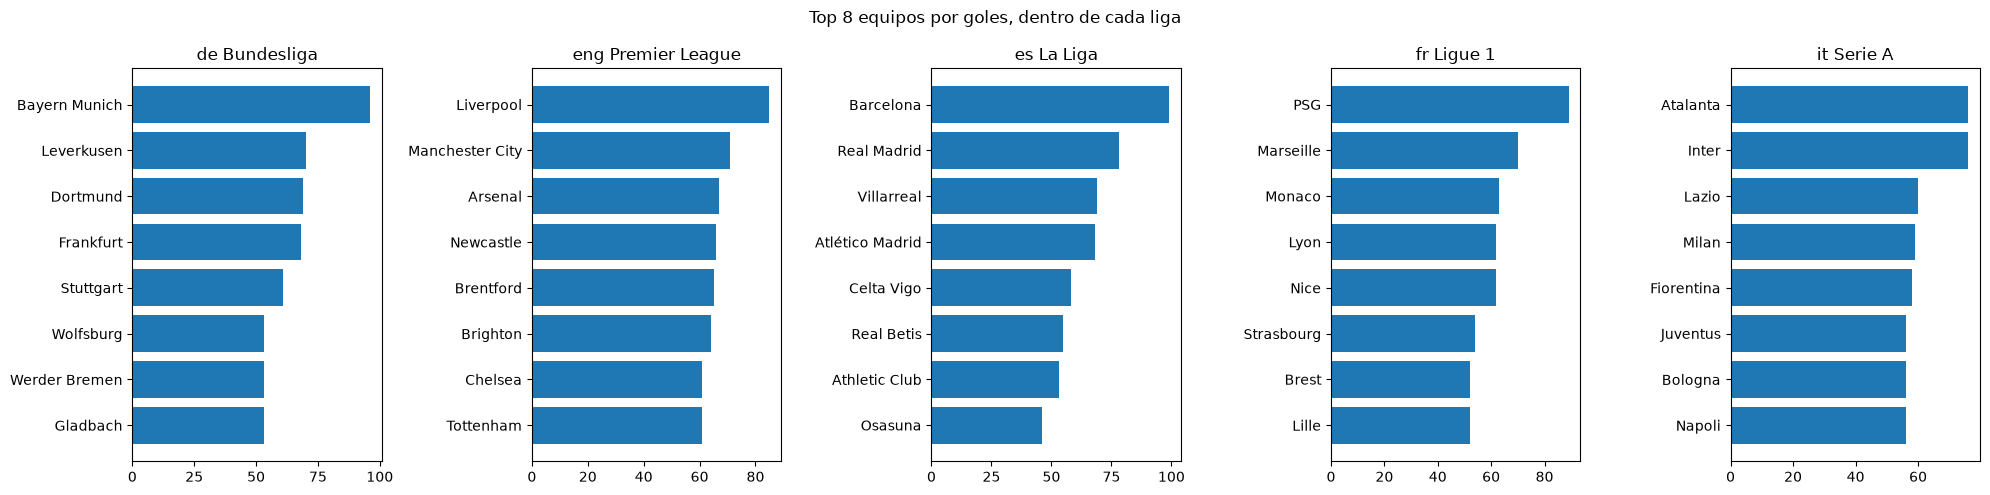

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharex=False)
for ax, liga in zip(axes, sorted(equipos["comp_level"].unique())):
    top = equipos[equipos["comp_level"] == liga].sort_values("goles", ascending=False).head(8)
    ax.barh(top["team"], top["goles"])
    ax.set_title(liga)
    ax.invert_yaxis()
fig.suptitle("Top 8 equipos por goles, dentro de cada liga")
fig.tight_layout()

## Ataque vs. disciplina

¿Los equipos más ofensivos son también los que más tarjetas acumulan (más
presión, más faltas tácticas), o son cosas independientes?

Correlación goles vs. amarillas: -0.41


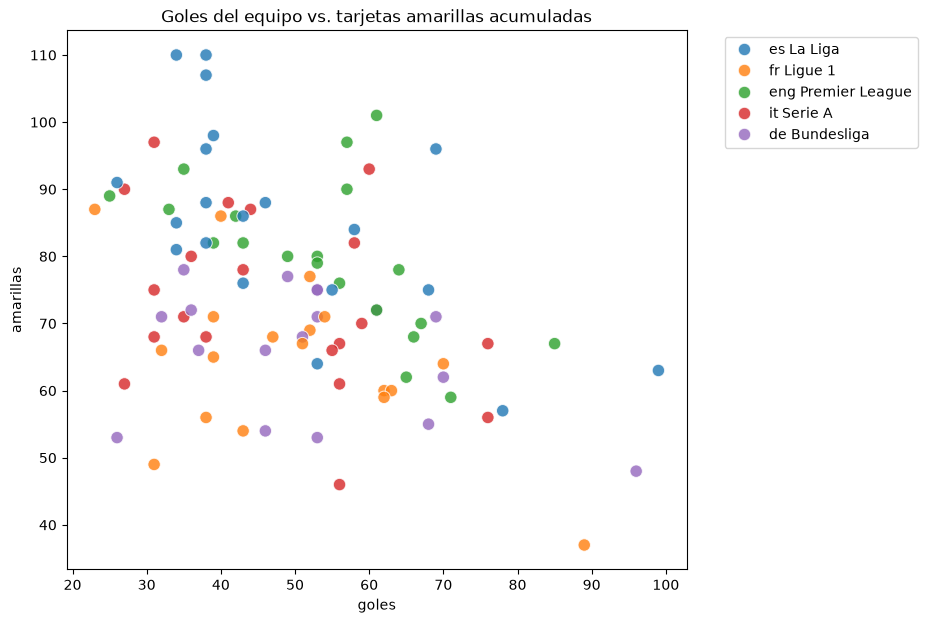

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=equipos, x="goles", y="amarillas", hue="comp_level", s=80, alpha=0.8, ax=ax)
ax.set_title("Goles del equipo vs. tarjetas amarillas acumuladas")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

print("Correlación goles vs. amarillas:", equipos["goles"].corr(equipos["amarillas"]).round(2))

## Dependencia de un solo jugador

¿Qué porcentaje de los goles de cada equipo vienen de su máximo goleador?
Un número alto sugiere un equipo muy dependiente de una sola pieza.

In [ ]:
max_goleador = (
    df.sort_values("goals", ascending=False)
    .groupby("team")
    .first()[["player", "goals"]]
    .rename(columns={"player": "maximo_goleador", "goals": "goles_max_goleador"})
)

dependencia = equipos.merge(max_goleador, on="team")
dependencia["pct_goles_de_su_goleador"] = (
    dependencia["goles_max_goleador"] / dependencia["goles"].replace(0, pd.NA) * 100
).round(1)

dependencia[dependencia["goles"] >= 20].sort_values("pct_goles_de_su_goleador", ascending=False)[
    ["team", "comp_level", "maximo_goleador", "goles_max_goleador", "goles", "pct_goles_de_su_goleador"]
].head(10)

## Guardar tabla de equipos

Para usarla en Tableau (Fase 6 del plan) o en análisis posteriores.

In [ ]:
equipos.to_csv("../data/processed/fbref_equipos_2025.csv", index=False)
print("Guardado en data/processed/fbref_equipos_2025.csv")

## Siguiente paso

Volver a jugador, pero más a fondo: reemplazar los datos sintéticos de
`06_scouting_percentiles_similaridad.ipynb` por este dataset real de FBref,
calculando percentiles **por posición** (no contra todo el mundo, como acá) y
buscando jugadores similares dentro de esa misma tabla.